# TSNPE on unif_norm

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/tsnpe/"

# TSNPE

Below, we plot the posterior approximation for a specific sequential posterior

In [31]:
sequential_posterior_ID = 1

# Load pre-trained posterior
sequential_posterior_name = f"sequential_posterior{sequential_posterior_ID}"
path_to_sequential_posterior = results_path + sequential_posterior_name + ".pkl"
path_to_sequential_density_estimator = results_path + sequential_posterior_name + "_density_estimator" + ".pkl"
path_to_sequential_posterior_config = results_path + sequential_posterior_name + ".yaml"
path_to_sequential_posterior_simulations = results_path + sequential_posterior_name + "_simulations" + ".npz"

# Load posterior
with open(path_to_sequential_posterior, "rb") as f:
    sequential_posterior = pickle.load(f)

# Load density estimator
with open(path_to_sequential_density_estimator, "rb") as f:
    sequential_density_estimator = pickle.load(f)

# Load config
with open(path_to_sequential_posterior_config, "r") as f:
    sequential_posterior_config = yaml.safe_load(f)

# Load samples
sequential_posterior_simulations = np.load(path_to_sequential_posterior_simulations)

x_observed = sequential_posterior_config["x_observed"]
sigma = sequential_posterior_config["sigma"]
d = sequential_posterior_config["d"]
L = sequential_posterior_config["L"]
U = sequential_posterior_config["U"]
num_sequential_rounds = sequential_posterior_config["num_sequential_rounds"]
num_simulations_per_round = sequential_posterior_config["num_simulations_per_round"]

print("Sequential posterior config:")
sequential_posterior_config

Sequential posterior config:


{'L': -1.0,
 'U': 1.0,
 'd': 1,
 'epsilon': 0.0001,
 'num_samples_to_estimate_support': 1000000,
 'num_sequential_rounds': 4,
 'num_simulations_per_round': 5000,
 'restricted_prior_sample_with': 'rejection',
 'save_samples_high_d': False,
 'sigma': 1.0,
 'simulation_times': [0.305317917,
  0.012608582999998674,
  0.012619915999998454,
  0.04902604200000127],
 'total_time': 48.331040083000005,
 'training_times': [8.290549042,
  15.851793583000001,
  11.124018374999999,
  12.685106625000003],
 'x_observed': [0.8]}

In [32]:
num_plotting_samples = 100000
sequential_density_estimator_samples = sequential_density_estimator.sample((num_plotting_samples,), condition=torch.tensor([x_observed])).detach().view(-1)
sequential_posterior_samples = sequential_posterior.sample((num_plotting_samples,), x=x_observed, show_progress_bars=False).view(-1)

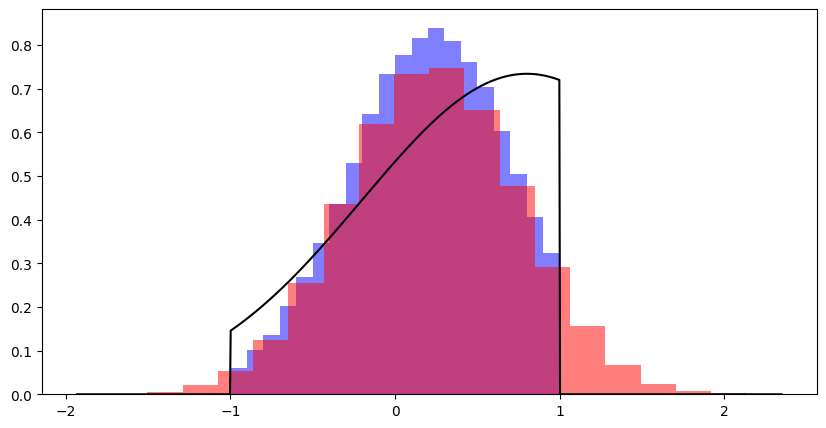

In [33]:
fig, ax = plt.subplots(figsize=(10,5))

bins=20
xlim0 = float(min(sequential_density_estimator_samples))
xlim1 = float(max(sequential_density_estimator_samples))
mu_range = np.linspace(xlim0, xlim1, 1000)

# ADD AXES AND TITLE
ax.hist(sequential_posterior_samples, density=True, bins=bins, color="blue", alpha=0.5)
ax.hist(sequential_density_estimator_samples, density=True, bins=bins, color="red", alpha=0.5)
ax.plot(mu_range, true_posterior_pdf(mu_range, x_observed[0], L=L, U=U, sigma=sigma), color="black")

plt.show()

Plot quantiles of sequential posterior for various values of $x$.

- Without training samples

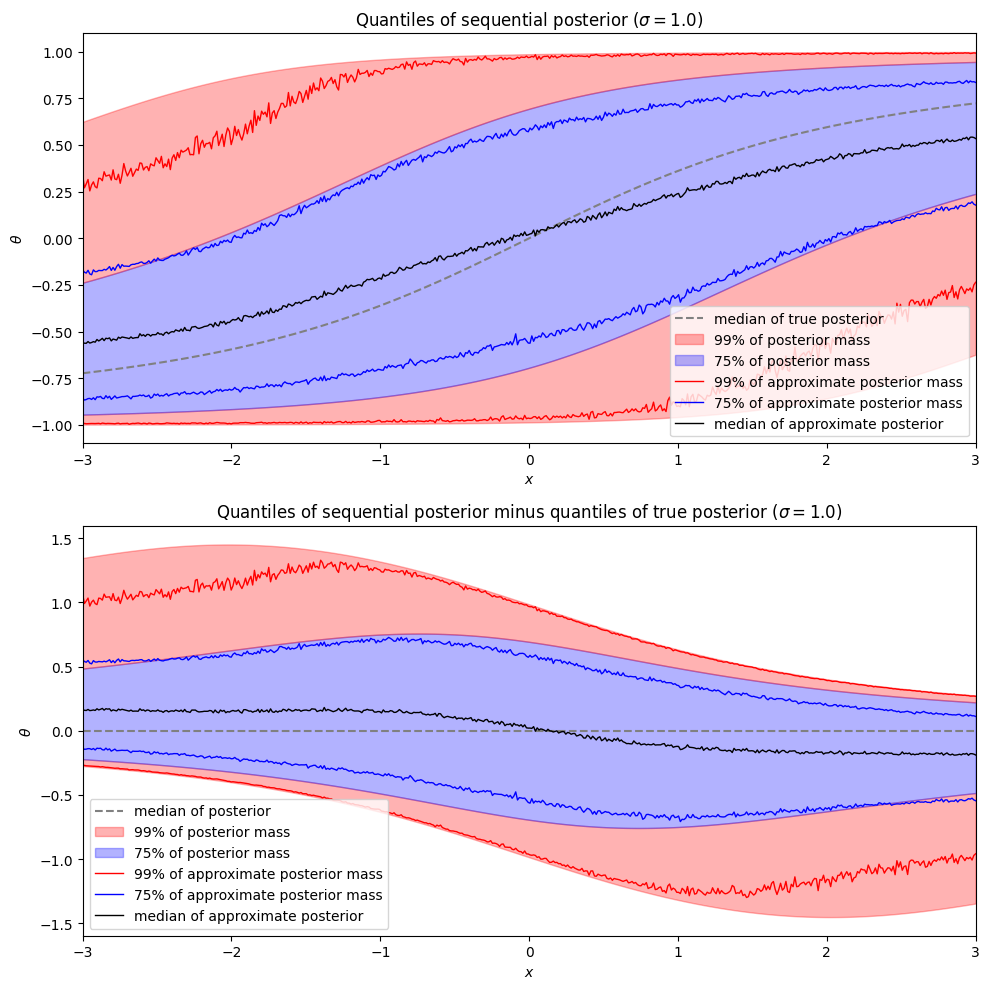

In [34]:
fig, ax = plt.subplots(figsize=(10,10), nrows=2)

x_range = np.linspace(L-2,U+2,500)
quantiles = approximate_posterior_quantiles_against_x(sequential_posterior, x_range)

title = "Quantiles of sequential posterior" + r" ($\sigma = $" + f"{sigma})"
plot_approximate_posterior_quantiles_against_x(x_range, quantiles, sigma, L, U, title=title, ax=ax[0])

title = "Quantiles of sequential posterior minus quantiles of true posterior" + r" ($\sigma = $" + f"{sigma})"
plot_approximate_posterior_quantiles_diff_against_x(x_range, quantiles, sigma, L, U, title=title, ax=ax[1])

plt.tight_layout()
plt.show()

- With training samples

In [35]:
# Retrieve samples
num_sequential_rounds = sequential_posterior_config["num_sequential_rounds"]
parameter_samples_per_round = []
data_samples_per_round = []
for r in range(num_sequential_rounds):
    parameter_samples_per_round.append(sequential_posterior_simulations[f"parameter_samples_round_{r}"].reshape(-1))
    data_samples_per_round.append(sequential_posterior_simulations[f"data_samples_round_{r}"].reshape(-1))

sequential_posterior_samples = {"parameter_samples": parameter_samples_per_round,
                                "data_samples": data_samples_per_round}

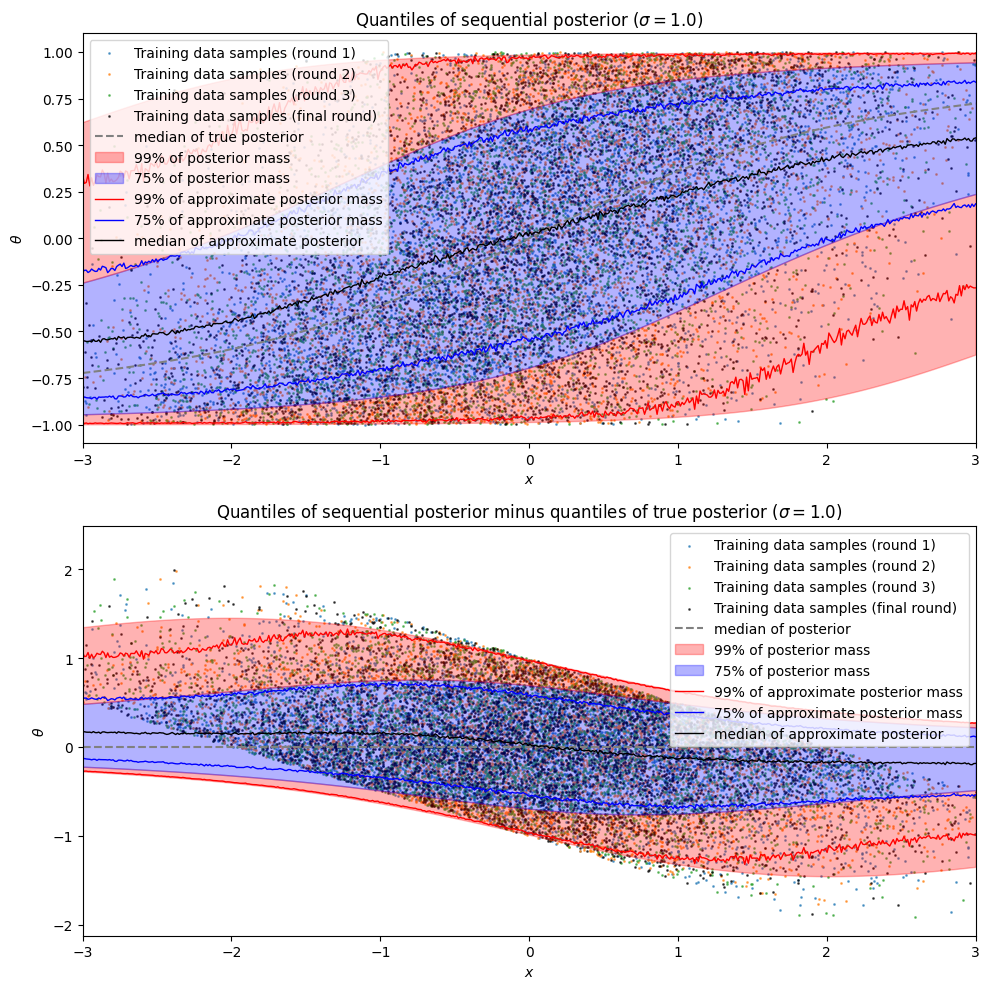

In [36]:
fig, ax = plt.subplots(figsize=(10,10), nrows=2)

x_range = np.linspace(L-2,U+2,500)
quantiles = approximate_posterior_quantiles_against_x(sequential_posterior, x_range)

title = "Quantiles of sequential posterior" + r" ($\sigma = $" + f"{sigma})"
plot_approximate_posterior_quantiles_against_x(x_range, quantiles, sigma, L, U, title=title, ax=ax[0], samples=sequential_posterior_samples)

title = "Quantiles of sequential posterior minus quantiles of true posterior" + r" ($\sigma = $" + f"{sigma})"
plot_approximate_posterior_quantiles_diff_against_x(x_range, quantiles, sigma, L, U, title=title, ax=ax[1], samples=sequential_posterior_samples)

plt.tight_layout()
plt.show()

$d=10$ sequential posterior

Recall that the analytical posterior for our model is 

$$\theta | x=x_\text{obs} \sim N_{[-L, L]^d}(x_\text{obs}, \sigma^2 I_d)$$

Suppose we set $\sigma^2 = 1$ and we condition on observing $x_\text{obs}=0$, then our posterior is

$$\theta | x=0 \sim N_{[-L, L]^d}(0, I_d)$$

In this case, we aim to select the uniform bounds of the form $[-L, L]^d$ such that the posterior is approximately Gaussian (i.e. the truncation is neglible, because most of the mass of the Gaussian is inside $[-L, L]^d$). We can find an exact expression for $L$ since the elements of our posterior vectors are independent $N(0,1)$:

$$P\left( \bigcap_{i=1}^d \{\theta_i \in [-L,L]\} \right) = \prod_{i=1}^d P\left(\theta_i \in [-L,L]\right)$$

$$ = \left( \Phi(L) - \Phi(-L)\right)^d = \left( 2\Phi(L) - 1\right)^d$$

Thus, if we want a cube region that contains the vector with probability $p^* \in [0,1]$, we solve

$$\left( 2\Phi(L) - 1\right)^d \overset{\text{set}}{=} p^*$$

$$\implies L = \Phi^{-1}\left( \frac{(p^*)^\frac{1}{d} + 1}{2}\right)$$

We can also obtain a spherical CI for the vector, using the fact that $||\theta||^2 \sim \chi^2_d$:

$$P\left(||\theta|| \le R \right) = P\left(||\theta||^2 \le R^2 \right)$$

$$=F_{\chi^2_d}(R^2)$$

Thus, if we want a spherical region that contains the vector with probability $p^* \in [0,1]$, we solve

$$F_{\chi^2_d}(R^2) = p^*$$

$$\implies R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

Note that, for fixed $p^*$, the spherical CI clearly "spills outside" of the box CI. However, we choose to select $L$ to equal the radius of the spherical CI:

$$L = R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

which ensures that the $p^*$ probability region containing the vector is a sphere inscribed within the prior bounds. This allows us to examine what happens as we increase the dimension $d$, since the volume ratio of the $p^*$ probability sphere of the posterior divided by the volume of the prior bounds :

$$\frac{\text{vol}\left( \{\theta : ||\theta|| \le L\} \right)}{\text{vol}([-L,L]^d)} = \frac{\pi^{d/2}L^d}{(2L)^d \Gamma(1 + d/2)} = \left(\frac{\sqrt{\pi}}{2}\right)^d\frac{1}{\Gamma(1 + d/2)}$$

goes to zero as $d \to \infty$.

Intuitively, $p^*$ (usually 0.99) of the posterior mass is contained within the sphere with radius $L$, and this sphere is inscribed inside the prior region $[-L,L]^d$, where the ratio of the volume of the $p^*$ region to the volume of the prior region goes to zero as $d \to \infty$. Thus, we expect the inference algorithms to struggle as $d$ gets larger, since the prior mass region becomes tiny compared to the prior region.


In [37]:
def get_spherical_confidence_region(d, p=0.99):
    # Return the R such that a MVN(0,I_d) vector is contained in the sphere with radius R w/p p
    R_squared = scipy.stats.chi2.ppf(p, d)
    return np.sqrt(R_squared)


def get_cube_confidence_region(d, p=0.99):
    # Return the L such that a MVN(0, I_d) vector is contained in [-L,L]^d w/p p
    L = scipy.stats.norm.ppf((p**(1/d) + 1)/2)
    return L


def vol_ratio(L, d):
    # Return volume ratio of a sphere of radius L inscribed inside [-L,L]^d
    vol_sphere = np.pi**(d/2) * L ** d / scipy.special.gamma(1 + d/2)
    vol_cube = (2*L)**d
    return vol_sphere/ vol_cube


def log10_vol_ratio(L, d):
    # Return log base 10 of volume ratio of a sphere of radius L inscribed inside [-L,L]^d
    log_vol_sphere = (d/2) * np.log10(np.pi) + d * np.log10(L) - np.log10(scipy.special.gamma(1 + d/2))
    log_vol_cube = d * np.log10(2*L)
    return log_vol_sphere - log_vol_cube

In [38]:
dim = 25
R = get_spherical_confidence_region(d=dim, p=0.99)
print(f"L = R = {R}")
vr = vol_ratio(L=R, d=dim)
print(f"Volume ratio is {vr}")

L = R = 6.656884023041046
Volume ratio is 2.854235198566831e-11


In [ ]:
# YET TO TRAIN A HIGH-D TSNPE POSTERIOR! 
sequential_posterior_ID = 2

# Load pre-trained posterior
sequential_posterior_name = f"sequential_posterior{sequential_posterior_ID}"
path_to_sequential_posterior = results_path + sequential_posterior_name + ".pkl"
path_to_sequential_density_estimator = results_path + sequential_posterior_name + "_density_estimator" + ".pkl"
path_to_sequential_posterior_config = results_path + sequential_posterior_name + ".yaml"
path_to_sequential_posterior_simulations = results_path + sequential_posterior_name + "_simulations" + ".npz"

# Load posterior
with open(path_to_sequential_posterior, "rb") as f:
    sequential_posterior = pickle.load(f)

# Load density estimator
with open(path_to_sequential_density_estimator, "rb") as f:
    sequential_density_estimator = pickle.load(f)

# Load config
with open(path_to_sequential_posterior_config, "r") as f:
    sequential_posterior_config = yaml.safe_load(f)

# Load samples
sequential_posterior_simulations = dict(np.load(path_to_sequential_posterior_simulations))

x_observed = sequential_posterior_config["x_observed"]
sigma = sequential_posterior_config["sigma"]
d = sequential_posterior_config["d"]
L = sequential_posterior_config["L"]
U = sequential_posterior_config["U"]
num_sequential_rounds = sequential_posterior_config["num_sequential_rounds"]
num_simulations_per_round = sequential_posterior_config["num_simulations_per_round"]

print("Sequential posterior config:")
sequential_posterior_config

In [175]:
# MOVE TO SRC CODE WHEN HAPPY
def plot_training_parameter_squared_norms(sequential_posterior_simulations, d, exclude_rounds=None, alpha=0.1):
    # List of rounds to exclude from plot
    if exclude_rounds is None:
        exclude_rounds = []
    fig, ax = plt.subplots(figsize=(10,5))
    ax.set_xlabel("Round")
    ax.set_ylabel(r"Average $||\theta||^2$ from round's proposal")
    mean_squared_norms = []
    lq_squared_norms = []
    uq_squared_norms = []
    rs = []

    r = 0
    while f"parameter_samples_round_{r}" in sequential_posterior_simulations:
        if not r in exclude_rounds:
            param_samples = sequential_posterior_simulations[f"parameter_samples_round_{r}"]
            squared_norms = (param_samples**2).sum(axis=1)
            mean_squared_norm = np.mean(squared_norms)
            lq_squared_norm = np.quantile(squared_norms, alpha / 2)
            uq_squared_norm = np.quantile(squared_norms, 1 - alpha / 2)
            mean_squared_norms.append(mean_squared_norm)
            lq_squared_norms.append(lq_squared_norm)
            uq_squared_norms.append(uq_squared_norm)
            rs.append(r)
        r += 1

    quantiles = np.array([np.array(mean_squared_norms) - lq_squared_norms,
                          uq_squared_norms - np.array(mean_squared_norms)])
    true_lq = scipy.stats.chi2.ppf(alpha / 2, df=d)
    true_uq = scipy.stats.chi2.ppf(1 - alpha / 2, df=d)
    
    ax.errorbar(rs, mean_squared_norms, yerr=quantiles, fmt='o', label="Mean and quantiles per round")
    ax.axhline(d, color="k", label="True mean")
    ax.fill_between(rs, true_lq, true_uq, alpha=0.4, color="gray", label="True quantiles")
    ax.set_title(f"Mean, {100*alpha/2}, and {100*(1-alpha/2)} quantiles of " + r"$||\theta||^2$ per round")

In [ ]:
plot_training_parameter_squared_norms(sequential_posterior_simulations, d=d, exclude_rounds=[0])

In [133]:
# MOVE TO SRC CODE WHEN HAPPY
def plot_training_parameter_squared_norms_hist(sequential_posterior_simulations, d, exclude_rounds=None, alpha=0.1, bins=None, histtype="step"):
    # List of rounds to exclude from plot
    if exclude_rounds is None:
        exclude_rounds = []
    fig, ax = plt.subplots(figsize=(10,5))
    ax.set_xlabel(r"$||\theta||^2$")
    r = 0
    while f"parameter_samples_round_{r}" in sequential_posterior_simulations:
        if not r in exclude_rounds:
            color = plt.gca()._get_lines.get_next_color()
            param_samples = sequential_posterior_simulations[f"parameter_samples_round_{r}"]
            squared_norms = (param_samples**2).sum(axis=1)
            if bins is not None:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r}", bins=bins, color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, bins=bins, color=color, label=f"Round {r}", histtype=histtype)
            else:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r}", color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, color=color, label=f"Round {r}", histtype=histtype)
        r += 1
    xl, xu = ax.get_xlim()
    x_range = np.linspace(xl, xu, 1000)
    ax.plot(x_range, scipy.stats.chi2.pdf(x_range, df=d), color="k", label=r"pdf of $\chi^2_d$")
    ax.legend()

In [ ]:
plot_training_parameter_squared_norms_hist(sequential_posterior_simulations, d, alpha=0.7,
                                           exclude_rounds=[0,1,2,3,4,5], bins=20, histtype="step")

## SBC on SNPE-C

In [43]:
sequential_sbc_ID = 0

# Load pre-trained sbc ranks
sequential_ranks_name = f"sequential_sbc_ranks{sequential_sbc_ID}"
path_to_sequential_ranks = results_path + sequential_ranks_name + ".npz"
path_to_sequential_ranks_config = results_path + sequential_ranks_name + ".yaml"

# Load sbc ranks
sequential_ranks = np.load(path_to_sequential_ranks)
sequential_ranks = dict(sequential_ranks)

# Load config
with open(path_to_sequential_ranks_config, "r") as f:
    sequential_ranks_config = yaml.safe_load(f)

# Load samples ONLY FOR 1D examples:
if sequential_ranks_config["d"] == 1:
    path_to_sequential_ranks_simulations = results_path + sequential_ranks_name + "_simulations" + ".npz"
    sequential_ranks_simulations = np.load(path_to_sequential_ranks_simulations)
    sequential_ranks = sequential_ranks[""]

N_iter = sequential_ranks_config["N_iter"]
N_samp = sequential_ranks_config["N_samp"]

print(f"Sequential SBC config:")
sequential_ranks_config

Sequential SBC config:


{'L': -1.0,
 'N_iter': 313,
 'N_samp': 10000,
 'U': 1.0,
 'd': 10,
 'epsilon': 0.0001,
 'num_sequential_rounds': 4,
 'num_simulations_per_round': 5000,
 'restricted_prior_sample_with': 'rejection',
 'num_samples_to_estimate_support': 1000000,
 'sample_with': 'direct',
 'sbc_times': [767.0272255381569,
  863.099377068691,
  1254.8977800998837,
  758.1098551228642,
  932.9378514634445,
  904.4310021791607,
  1041.5792471170425,
  1040.1339223692194,
  1012.0506380340084,
  908.663422207348,
  940.622620569542,
  768.0993983717635,
  798.0741260591894,
  968.5443614916876,
  1116.6166302664205,
  941.1410593288019,
  1048.5665596900508,
  852.4399147052318,
  774.1123974760994,
  1080.141529077664,
  811.7960567418486,
  833.4442723281682,
  984.6623323578387,
  1032.0426369598135,
  747.6220361934975,
  858.6460449397564,
  910.2252499992028,
  982.640398286283,
  810.867602863349,
  948.4136584904045,
  1024.9901204928756,
  668.9844542890787,
  969.2937699677423,
  1017.1784486863762,


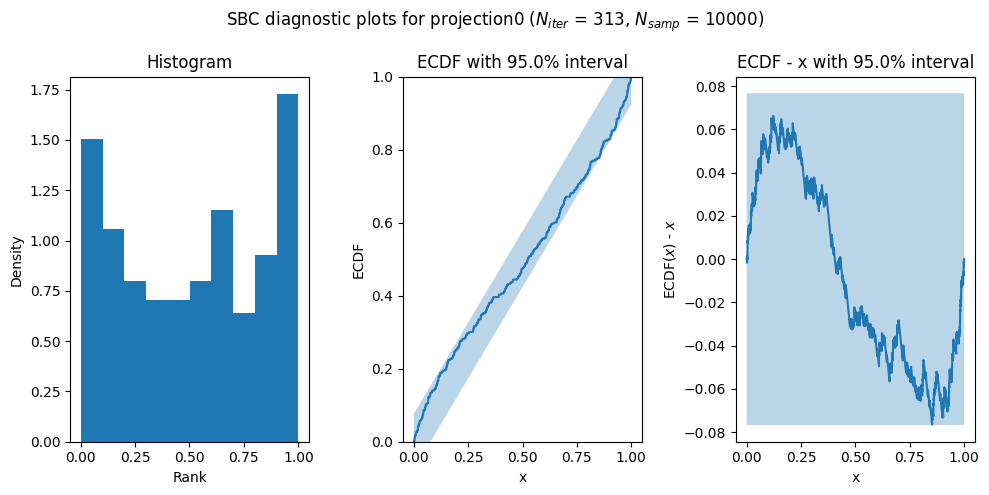

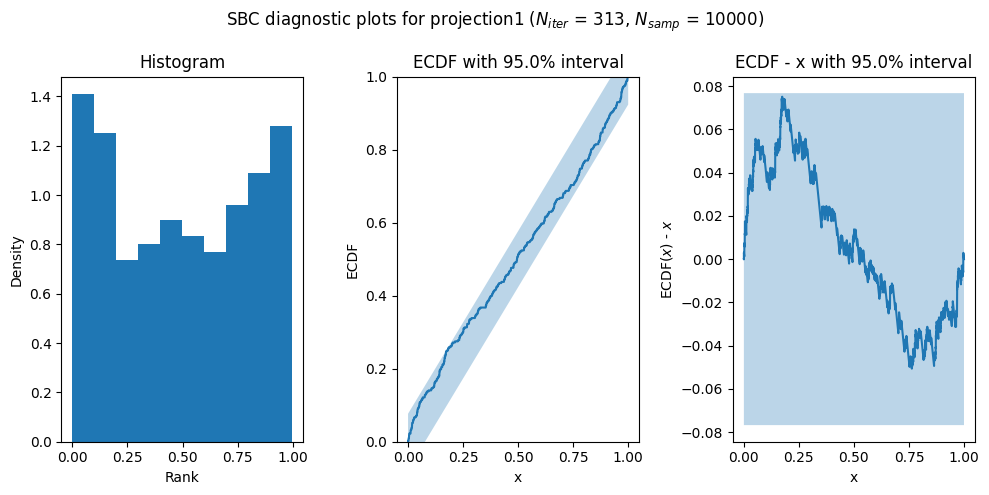

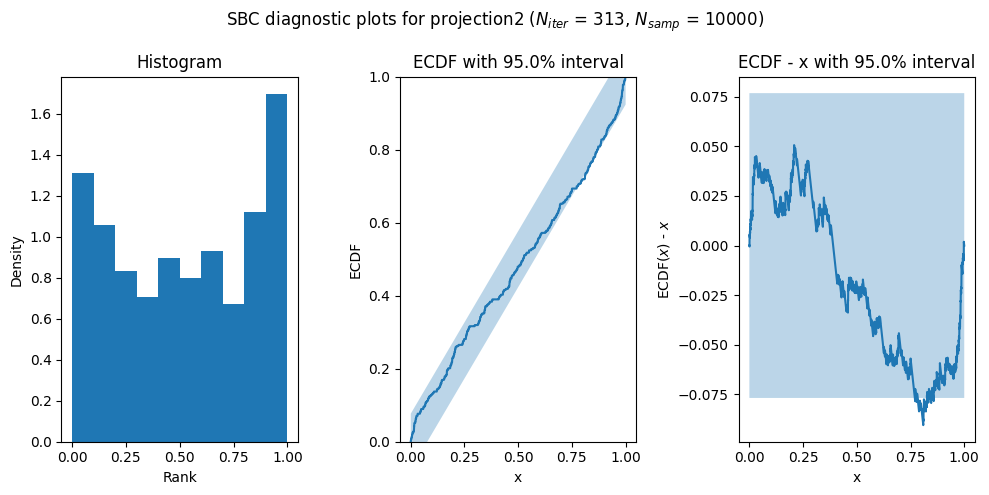

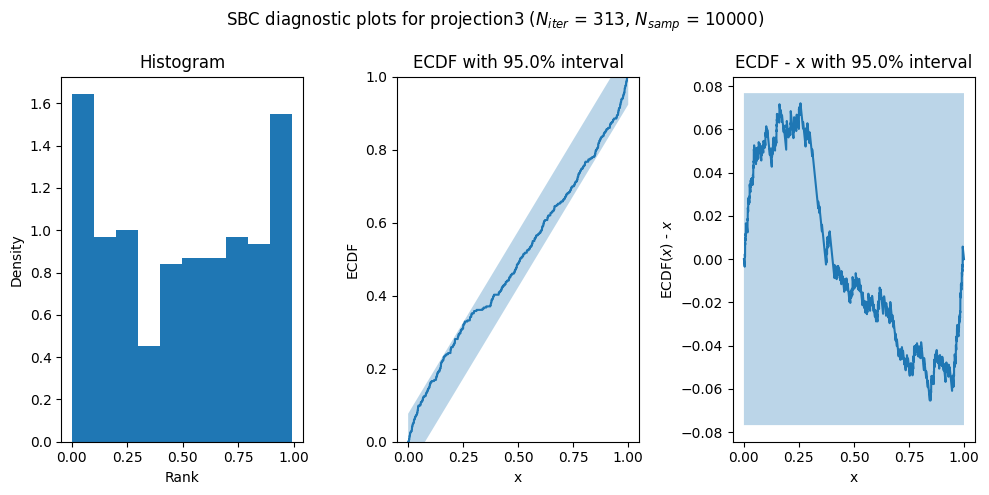

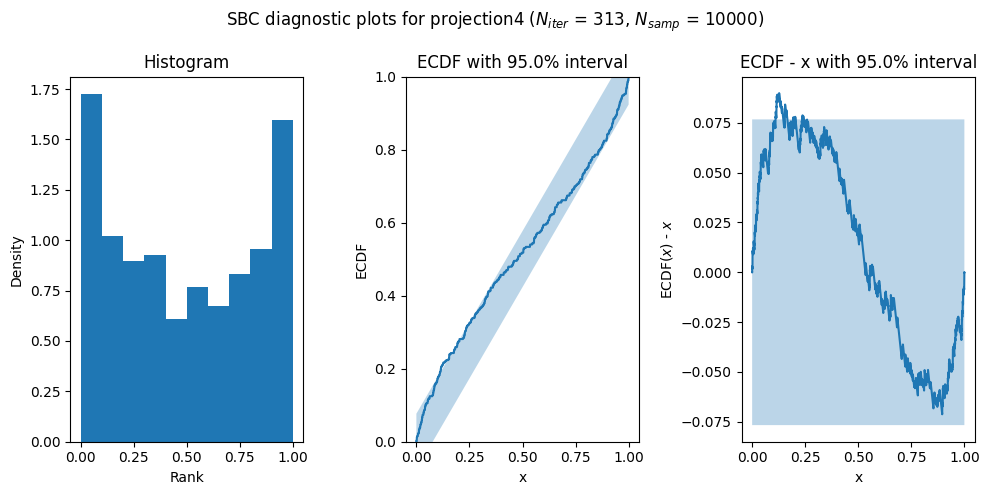

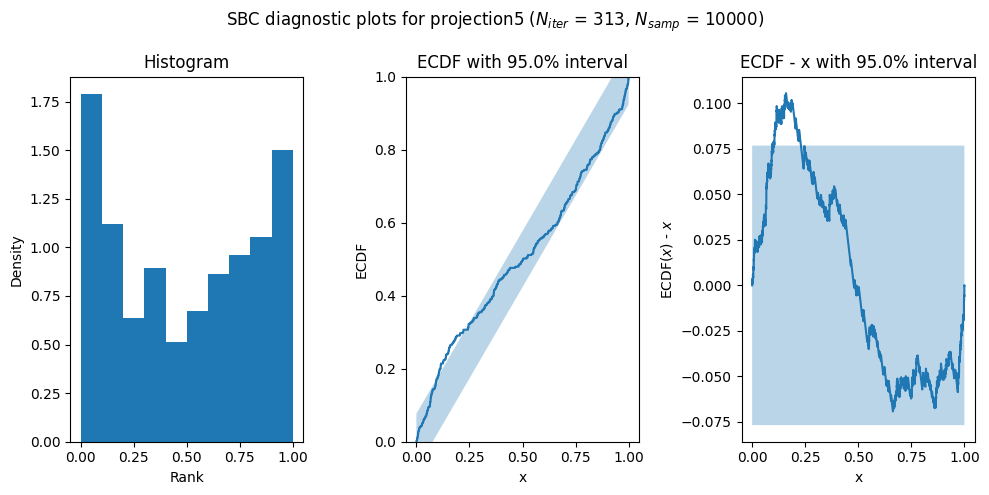

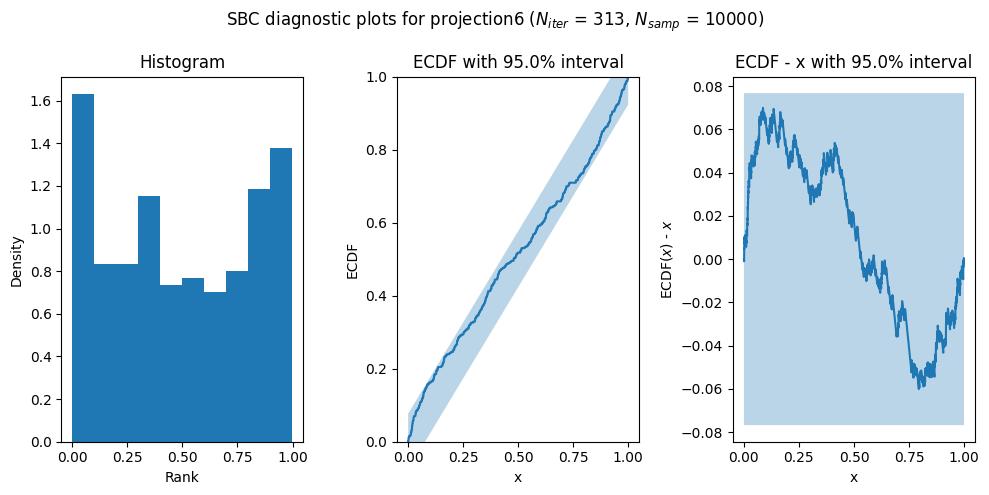

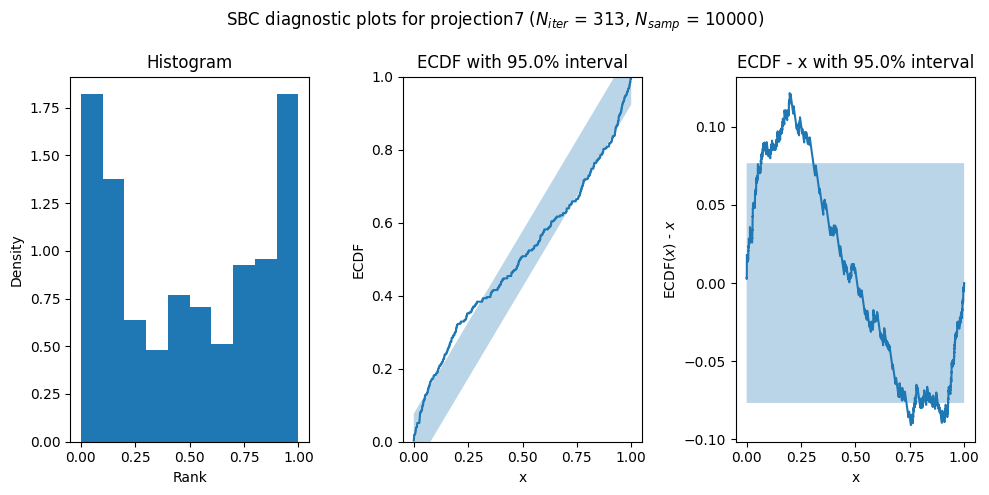

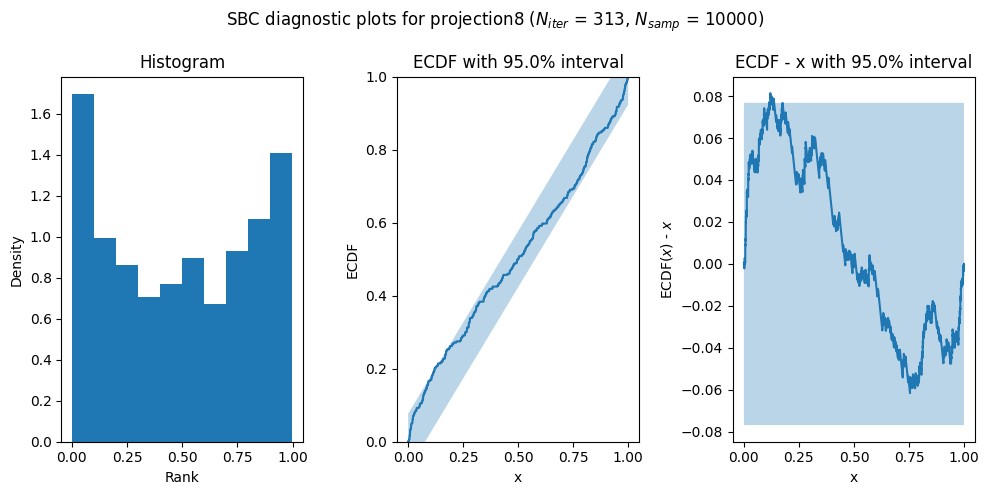

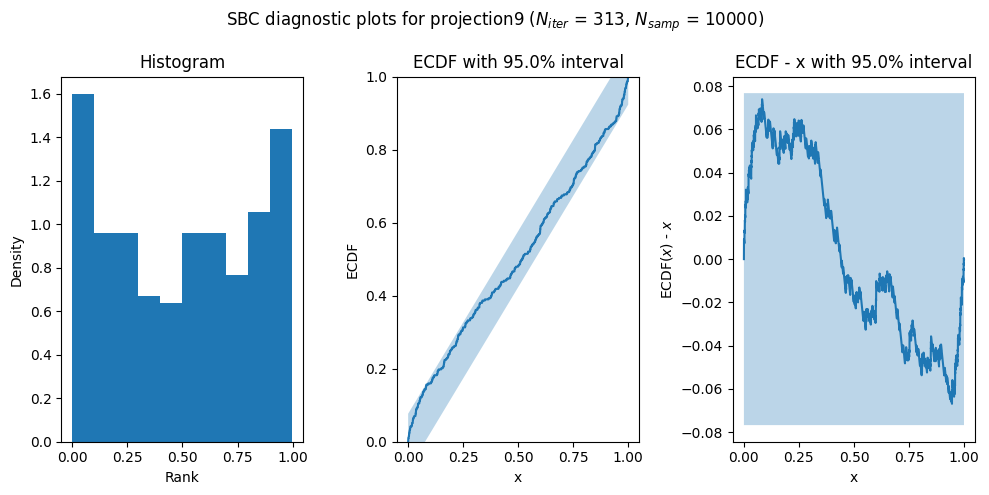

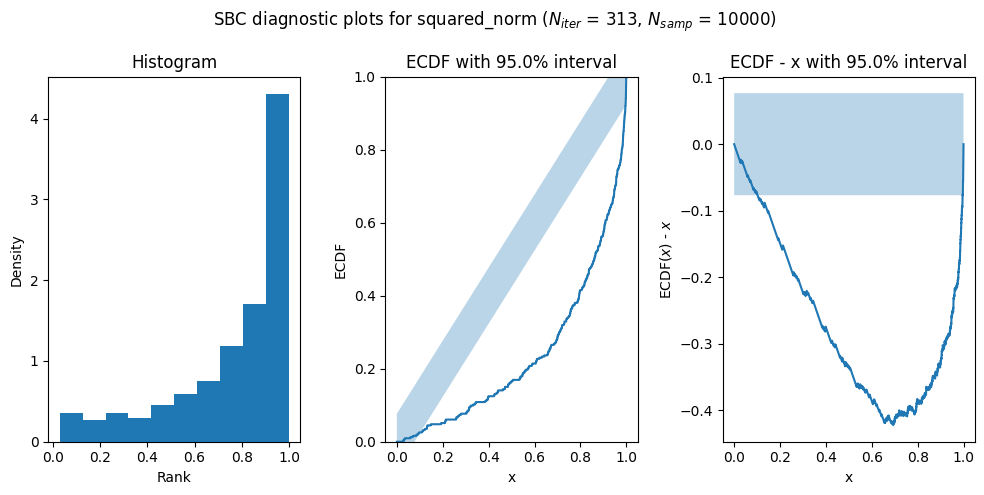

In [44]:
for test_function_name, ranks in sequential_ranks.items():
    title=fr"SBC diagnostic plots for {test_function_name}" + r" ($N_{iter}$ = " + f"{N_iter}, " + r"$N_{samp}$ = " + f"{N_samp})"
    plot_sbc_all(ranks=ranks, N_samp=N_samp, title=title)